# Aula 17 — Séries temporais financeiras: o índice é o tempo

**Semana 9** | 50 min | Referências: McKinney (2012), *Python for Data Analysis* —
Cap. 10 *Time Series* (`kb/01_mckinney_python_for_data_analysis/12_chapter-10-time-series.md`)
e Cap. 11 *Financial and Economic Data Applications* (`kb/01_mckinney_python_for_data_analysis/13_chapter-11-financial-and-economic-data-applications.md`);
Jansen (2021), *ML for Algorithmic Trading* — Cap. 9 (`kb/03_jansen_ml_for_algorithmic_trading/15_chapter-9-time-series-models-for-volatility-forecasts-and-st.md`).

Aula anterior: A16 (compra vs leasing) · Próxima: A18 (commodities agro e futuros)


## 🎯 Objetivos de aprendizagem

Ao final desta aula você será capaz de:

- Carregar séries do BCB e do Yahoo Finance com **datas corretas**: `pd.to_datetime`
  com `format` explícito e `dayfirst=True` para o padrão brasileiro `dd/mm/aaaa`;
- **Indexar e fatiar por data** com um `DatetimeIndex` (`df.loc['2025']`, `df.loc['2025-04']`);
- Construir **retornos e variações** com `pct_change` e `shift` (e `diff`), entendendo
  por que `shift` desloca o passado para o presente;
- Suavizar e agregat com **médias móveis** (`rolling(21)`, `rolling(252)`) e
  `resample` para frequências `ME`/`YE` (pandas 3.x);
- Gerar **calendários de dias úteis** com `pd.bdate_range` — o calendário de pagamentos
  e vencimentos do dia a dia da consultoria.

## 📂 Dados da aula (offline-first)

| arquivo | conteúdo | leitura |
|---|---|---|
| `../data/csv/selic_diaria_aa.csv` | Selic diária (% a.a.), BCB-SGS 1178 | `sep=';'`, `decimal=','`, `dayfirst=True` |
| `../data/csv/usdbrl_diario.csv` | Câmbio PTAX diário (R$/US$), BCB-SGS 1 | idem |
| `../data/csv/soja_cbot_usd_bushel.csv` | Futuro soja CBOT (US$/bushel) | `date` já em `YYYY-MM-DD` |

> **ÚNICA exceção offline do curso:** a Seção 2 tem uma célula opcional de coleta ao
> vivo (`yfinance`) envolvida em `try/except` — se não houver internet (ou yfinance
> instalado), ela avisa e usa o CSV local. O resto da aula roda 100% offline.

In [1]:
# Setup — imports e padrões visuais usados na aula
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

def brl(x):
    """Formata um número como moeda brasileira: R$ 1.234,56."""
    return f"R$ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

np.random.seed(42)  # reprodutibilidade quando houver aleatoriedade

print("pandas:", pd.__version__)


pandas: 3.0.5


## 1. Por que datas importam: preço é função do tempo

**Intuição econômica.** O analista quase nunca pergunta *qual* é a Selic — ele pergunta
*quando*. "Quanto o dólar subiu desde a assinatura do contrato?", "qual a média da soja
no trimestre da safra?", "o dia 4 de abril de 2025 foi normal?" — todas as perguntas
de trabalho têm uma **data** (ou um período) dentro delas.

Num DataFrame comum, a data é só mais uma coluna de texto: `"02/01/2017"`. O pandas
não sabe ordenar períodos, não sabe somar um mês, não sabe que 04/07 é dia útil.
Quando a data vira o **índice** (`DatetimeIndex`), a tabela se torna uma *série
temporal*: fatiar por ano, por mês, comparar períodos e calcular janelas móveis passa
a ser uma linha de código.

O erro clássico que a aula evita: a data `02/03/2026` é 2 de março ou 3 de fevereiro?
Depende do padrão — no Brasil é 2 de março; no padrão ISO/US é 3 de fevereiro. Por isso
o `format` **explícito** e o `dayfirst=True` são obrigatórios nos dados do BCB.

In [2]:
# Datas como texto são só texto: pandas não entende calendário
from pathlib import Path
DATA = Path("../data/csv")  # notebook mora em semana_09/

texto = "02/03/2026"
print("texto:", texto, "| tipo:", type(texto))
# print(texto + pd.offsets.BDay(1))  # -> TypeError: str não entende dia útil


texto: 02/03/2026 | tipo: <class 'str'>


In [3]:
# pd.to_datetime transforma texto em data de verdade — com formato EXPLÍCITO
d_br = pd.to_datetime("02/03/2026", format="%d/%m/%Y", dayfirst=True)  # padrão BCB
d_iso = pd.to_datetime("2026-03-02", format="%Y-%m-%d")               # padrão Yahoo

print("dd/mm/aaaa (dayfirst):", d_br.date())
print("aaaa-mm-dd           :", d_iso.date())
print("mesma data? ", d_br == d_iso)


dd/mm/aaaa (dayfirst): 2026-03-02
aaaa-mm-dd           : 2026-03-02
mesma data?  True


## 2. Carregando as séries do BCB e da CBOT

**Intuição econômica.** Três séries guiam a aula e a próxima:

- **Selic diária (% a.a.)** — o custo do dinheiro no Brasil; todo desconto de fluxo,
  custo de capital e comparação de rentabilidade parte dela;
- **Câmbio PTAX (R$/US$)** — a variável que converte preços em dólar (soja, milho,
  boi negociados na CBOT/CME) em receita em reais do produtor goiano;
- **Soja CBOT (US$/bushel)** — o preço internacional que chega ao mercado físico
  de Rio Verde e Jataí com frete, qualidade e sazonalidade no caminho (Aula 18).

Dois dialetos de data: o BCB grava `"02/01/2017"` (dd/mm/aaaa, `sep=';'`, vírgula
decimal); o Yahoo Finance grava `"2016-09-06"` (ISO). O notebook usa `format`
explícito em cada caso — nunca deixe o pandas adivinhar.

In [4]:
# Séries BCB: sep=';', decimal=',' e dayfirst=True — o dialeto brasileiro
selic = pd.read_csv(DATA / "selic_diaria_aa.csv", sep=";", decimal=",")
usd = pd.read_csv(DATA / "usdbrl_diario.csv", sep=";", decimal=",")

for df in (selic, usd):  # mesma transformação nas duas: parsear e indexar por data
    df["data"] = pd.to_datetime(df["data"], format="%d/%m/%Y", dayfirst=True)
    df.set_index("data", inplace=False)  # demonstração; atribuição abaixo (sem inplace)

selic = selic.set_index("data").sort_index()["valor"]
usd = usd.set_index("data").sort_index()["valor"]

print(selic.head(3))
print("período:", usd.index[0].date(), "→", usd.index[-1].date(), "| n =", len(usd))


data
2017-01-02    13.65
2017-01-03    13.65
2017-01-04    13.65
Name: valor, dtype: float64
período: 2017-01-02 → 2026-09-04 | n = 2429


In [5]:
# Série yfinance: date já em YYYY-MM-DD (ISO) — outro formato explícito
soja = pd.read_csv(DATA / "soja_cbot_usd_bushel.csv")
soja["date"] = pd.to_datetime(soja["date"], format="%Y-%m-%d")
soja = soja.set_index("date").sort_index()["close"]

print(soja.head(3))
print(f"soja CBOT: {soja.index[0].date()} → {soja.index[-1].date()} | "
      f"último: US$ {soja.iloc[-1]:,.0f}/contrato (=US$ {soja.iloc[-1]/100:.2f}/bu)".replace(",", "X"))


date
2016-09-06    974.25
2016-09-07    991.75
2016-09-08    992.00
Name: close, dtype: float64
soja CBOT: 2016-09-06 → 2026-09-04 | último: US$ 1X294/contrato (=US$ 12.94/bu)


### 2.1 Célula opcional — coleta ao vivo (não dependa dela)

Esta é a **única** célula com rede de todo o curso. Se houver internet e `yfinance`
instalado, ela baixa o câmbio BRL=X e compara com o CSV local; senão, avisa e segue
com o CSV. O padrão `try/except` é a receita de produção para dados externos.

In [6]:
# OPCIONAL — coleta ao vivo via yfinance (BRL=X). Roda sem internet, sem erro.
try:
    import yfinance as yf

    yf_usd = yf.download("BRL=X", start="2026-08-01", progress=False)
    # yfinance pode devolver colunas multi-nível ('Close', 'BRL=X') — achatar:
    if isinstance(yf_usd.columns, pd.MultiIndex):
        yf_usd.columns = yf_usd.columns.get_level_values(0)
    serie_viva = yf_usd["Close"].dropna()
    print(f"coleta ao vivo OK: {len(serie_viva)} dias "
          f"({serie_viva.index[0].date()} → {serie_viva.index[-1].date()})")
    print("comparação com CSV local (últimos 3):")
    comp = pd.DataFrame({"yahoo": serie_viva, "csv": usd}).dropna().tail(3)
    print(comp)
except Exception as e:  # sem internet, sem pacote, bloqueio — tudo cai aqui
    print(f"[fallback] coleta ao vivo indisponível ({type(e).__name__}: {e}).")
    print("Seguindo com o CSV local ../data/csv/usdbrl_diario.csv (offline-first).")


coleta ao vivo OK: 26 dias (2026-08-03 → 2026-09-07)
comparação com CSV local (últimos 3):
             yahoo     csv
2026-09-02  5.1522  5.1273
2026-09-03  5.0927  5.0962
2026-09-04  5.1010  5.1253


## 3. Indexação por data: fatiar a história

**Intuição econômica.** O relatório pede "a Selic média de 2025", "o câmbio de
abril/2025", "a soja do último trimestre". Com o `DatetimeIndex`, isso deixa de ser
filtro de planilha e vira **indexação com strings parciais**: `'2025'` é o ano
inteiro; `'2025-04'` é o mês; `'2025-04-04'` é o dia. O pandas expande a string
para o intervalo completo de datas.

In [7]:
# Fatias por string parcial: ano, mês, dia — sem .loc com máscara manual
print("Selic média 2025:", round(selic.loc['2025'].mean(), 2), "% a.a.")
print("Selic média abril/2025:", round(selic.loc['2025-04'].mean(), 2), "% a.a.")
print("Câmbio 04/abr/2025:", usd.loc['2025-04-04'])

# Intervalo: dois-pontos funciona com datas também
pedaco = usd.loc['2025-04-01':'2025-04-14']
print("dias úteis 01→14/abr/2025:", len(pedaco))


Selic média 2025: 14.33 % a.a.
Selic média abril/2025: 14.15 % a.a.
Câmbio 04/abr/2025: 5.7777
dias úteis 01→14/abr/2025: 10


In [8]:
# Antes/depois de virar índice: o ganho não é estética, é capacidade
usd_texto = pd.read_csv(DATA / "usdbrl_diario.csv", sep=";", decimal=",")
# usd_texto.loc['2025']            # -> KeyError: '2025' não é rótulo de linha
print("como texto: só colchetes numéricos e filtros manuais; como índice:")
print(usd.loc['2025'].shape, "linhas em 2025 — uma string.")


como texto: só colchetes numéricos e filtros manuais; como índice:
(252,) linhas em 2025 — uma string.


## 4. shift, pct_change e cumsum: transformar nível em movimento

**Intuição econômica.** Preço **nível** quase não diz nada; **variação** diz tudo.
O produtor não pergunta "quanto está a soja?" — pergunta "subiu quanto desde ontem,
desde o plantio, desde o ano passado?". As três ferramentas:

- `shift(n)` — empurra a série *n* passos para frente: em cada linha fica o valor de
  *n* dias atrás. É a ponte entre ontem e hoje;
- `pct_change()` — variação percentual vs. a linha anterior: `(hoje/ontem − 1)`;
- `.cumsum()` — soma acumulada: transforma retornos diários em trajetória acumulada.

O dia 4/abr/2025 ilustra o porquê: o dólar saltou de R$ 5,6067 para R$ 5,7777
(**+3,05%** em um dia, tarifaço dos EUA) e recuou −2,46% no dia seguinte. Nível
não mostra isso; `pct_change` mostra na hora.

In [9]:
# pct_change = variação percentual diária; shift = o valor de ontem na linha de hoje
usd_ret = usd.pct_change()          # equivalente a usd / usd.shift(1) - 1
usd_shift = usd.shift(1)            # valor de ONTEM alinhado na linha de HOJE

amostra = pd.DataFrame({
    "usd": usd.loc['2025-04-03':'2025-04-11'],
    "ontem (shift 1)": usd_shift.loc['2025-04-03':'2025-04-11'],
    "ret %": (usd_ret.loc['2025-04-03':'2025-04-11'] * 100).round(2),
})
print(amostra)
print("conferência manual 04/abr:", round((5.7777 / 5.6067 - 1) * 100, 2), "%")


               usd  ontem (shift 1)  ret %
data                                      
2025-04-03  5.6067           5.6923  -1.50
2025-04-04  5.7777           5.6067   3.05
2025-04-07  5.8877           5.7777   1.90
2025-04-08  5.9368           5.8877   0.83
2025-04-09  6.0605           5.9368   2.08
2025-04-10  5.9115           6.0605  -2.46
2025-04-11  5.8737           5.9115  -0.64
conferência manual 04/abr: 3.05 %


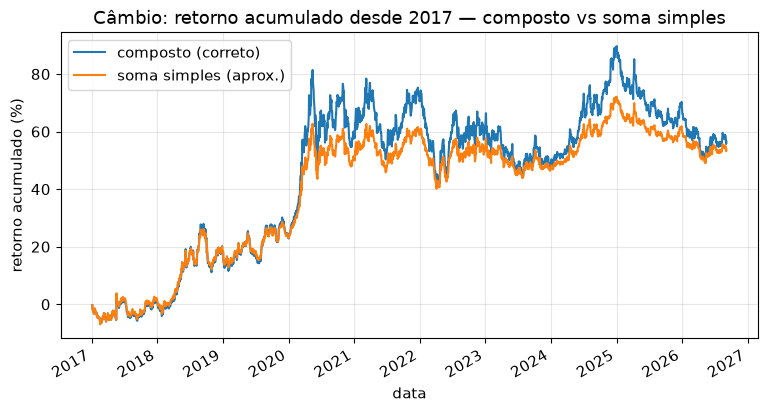

acumulado 2017→2026: composto 56.6 % | soma simples 53.8 % — diferença = juros sobre juros


In [10]:
# cumsum: trajetória acumulada dos retornos — o "desde o começo" de cada dia
usd_ret = usd.pct_change()
acumulado = (1 + usd_ret).cumprod() - 1          # retorno acumulado (composição)
soma_simples = usd_ret.cumsum()                  # soma simples (aprox. didática)

ax = (100 * pd.DataFrame({
    "composto (correto)": acumulado,
    "soma simples (aprox.)": soma_simples,
})).plot(title="Câmbio: retorno acumulado desde 2017 — composto vs soma simples")
ax.set_ylabel("retorno acumulado (%)")
ax.set_xlabel("data")
plt.show()

print("acumulado 2017→2026: composto", round(100*acumulado.iloc[-1], 1), "% |",
      "soma simples", round(100*soma_simples.iloc[-1], 1), "% — diferença = juros sobre juros")


## 5. rolling: médias móveis (MM21 e MM252)

**Intuição econômica.** O preço de hoje é ruído; a **média de uma janela** é a
tendência. Duas janelas padrão de mercado:

- **MM21** ≈ 1 mês de dias úteis — o curto prazo (o que o mercado está pagando agora);
- **MM252** ≈ 1 ano de dias úteis — a referência anual (onde o preço está vs. o ano).

`rolling(21).mean()` cria uma janela que **desliza** dia a dia: cada ponto é a média
dos 21 últimos. As primeiras 20 linhas ficam `NaN` (janela incompleta) — comportamento
correto, não bug. Quando a série rápida cruza a lenta para cima, o mercado fala em
"momentum de alta" — sinal que traders acompanham (Jansen, Cap. 9).

MM21 nas 25 primeiras linhas (NaN até a janela encher):
data
2017-01-02   NaN
2017-01-03   NaN
2017-01-04   NaN
Name: valor, dtype: float64
primeira MM252 válida: 2018-01-04


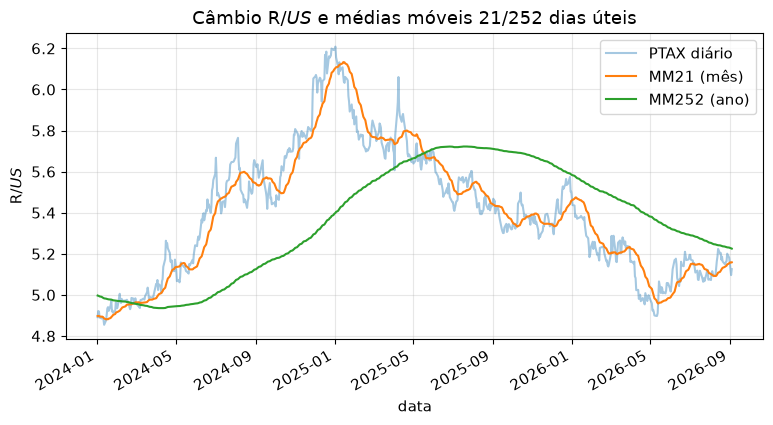

In [11]:
# Médias móveis: rolling(21) = mês útil; rolling(252) = ano útil
usd_mm21 = usd.rolling(21).mean()
usd_mm252 = usd.rolling(252).mean()

print("MM21 nas 25 primeiras linhas (NaN até a janela encher):")
print(usd_mm252.head(3))          # NaN: só 2 dias de história, janela de 252 vazia
print("primeira MM252 válida:", usd_mm252.first_valid_index().date())

ax = usd.loc['2024':].plot(alpha=0.4, label="PTAX diário", legend=True)
usd_mm21.loc['2024':].plot(ax=ax, label="MM21 (mês)")
usd_mm252.loc['2024':].plot(ax=ax, label="MM252 (ano)")
ax.set_title("Câmbio R$/US$ e médias móveis 21/252 dias úteis")
ax.set_ylabel("R$/US$")
ax.set_xlabel("data")
ax.legend()
plt.show()


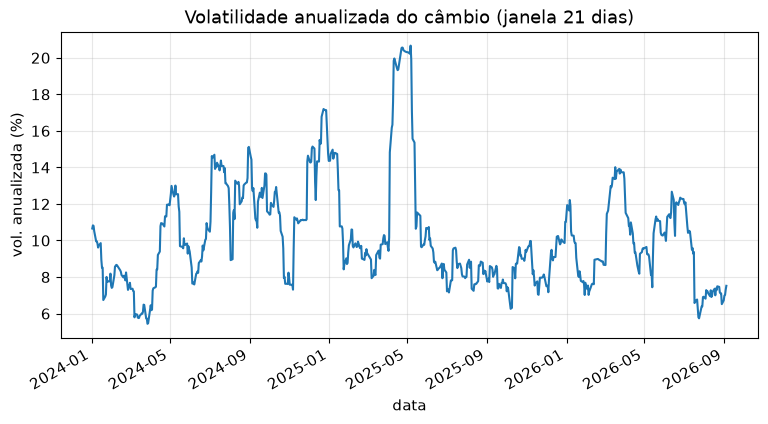

vol. anualizada mais recente: 7.5%


In [12]:
# rolling também faz desvio-padrão: volatilidade realizada em janela
vol_21 = usd.pct_change().rolling(21).std() * np.sqrt(252)  # anualizada (252 dias úteis)

ax = (100 * vol_21.loc['2024':]).plot(title="Volatilidade anualizada do câmbio (janela 21 dias)")
ax.set_ylabel("vol. anualizada (%)")
ax.set_xlabel("data")
plt.show()

print("vol. anualizada mais recente:", f"{100 * vol_21.iloc[-1]:.1f}%")


## 6. resample: mudar a frequência (ME / YE)

**Intuição econômica.** O relatório mensal do OIKOS não usa dados diários — usa o
**mês**. `resample('ME')` agrupa a série diária em fim de mês; `resample('YE')`, em
ano. Após o resample, escolhe a agregação: `.mean()` (nível médio do período),
`.last()` (fechamento do período), `.sum()` (para fluxos: retornos, volumes).

Regra prática: **nível → média ou último; fluxo → soma** (a Selic *a.a.* diária é
nível; o *retorno* diário é fluxo). No pandas 3.x os códigos são `'ME'` e `'YE'`
('M' e 'Y' puros foram aposentados).

In [13]:
# resample ME/YE: nível médio por mês e por ano-calendário
usd_mensal = usd.resample('ME').mean()   # média mensal
usd_anual = usd.resample('YE').mean()    # média anual

print(usd_mensal.loc['2025-01':'2025-03'].round(3))
print(usd_anual.loc['2024':].round(3))


data
2025-01-31    6.022
2025-02-28    5.766
2025-03-31    5.747
Freq: ME, Name: valor, dtype: float64
data
2024-12-31    5.392
2025-12-31    5.586
2026-12-31    5.148
Freq: YE-DEC, Name: valor, dtype: float64


In [14]:
# Mesma série, três leituras do mês: média, fechamento e amplitude
resumo_mensal = usd.loc['2025'].resample('ME').agg(['mean', 'last', 'min', 'max'])
resumo_mensal.columns = ['média', 'fechamento', 'mínimo', 'máximo']
print(resumo_mensal.round(3).head(6))

# Fluxo vs nível: retorno diário SOMA no período; o nível NÃO soma
ret_mensal = usd.pct_change().resample('ME').sum()  # aproximação didática da soma
print("\nretorno mensal (soma simples) abr/2025:",
      f"{100 * ret_mensal.loc['2025-04-30']:.2f}%")


            média  fechamento  mínimo  máximo
data                                         
2025-01-31  6.022       5.830   5.830   6.209
2025-02-28  5.766       5.849   5.698   5.869
2025-03-31  5.747       5.742   5.663   5.835
2025-04-30  5.784       5.661   5.607   6.060
2025-05-31  5.667       5.709   5.610   5.738
2025-06-30  5.547       5.457   5.457   5.694

retorno mensal (soma simples) abr/2025: -1.26%


## 7. pd.bdate_range: o calendário de dias úteis

**Intuição econômica.** Contrato, parcela, vencimento do futuro, relatório quinzenal:
quase nada na agenda da consultoria cai em fim de semana. `pd.bdate_range(início,
fim)` gera só **business days** — a espinha dorsal de qualquer cronograma financeiro.
Ele também é a forma correta de conferir se um índice de dados tem buracos
(feriados são esperados; datas úteis ausentes sem motivo, não).

In [15]:
# bdate_range: só dias úteis — a agenda do analista
uteis = pd.bdate_range('2026-09-01', '2026-09-30')
print("dias úteis de set/2026:", len(uteis))
print(uteis[:5])

# Comparando com o calendário real do dado BCB: feriados aparecem como buracos
setembro = usd.loc['2026-09-01':'2026-09-30']
print("dias com dado BCB no mesmo período:", len(setembro))


dias úteis de set/2026: 22
DatetimeIndex(['2026-09-01', '2026-09-02', '2026-09-03', '2026-09-04',
               '2026-09-07'],
              dtype='datetime64[us]', freq='B')
dias com dado BCB no mesmo período: 4


## 📝 Exercícios

Faça **antes** de abrir a solução. Cada enunciado tem contexto econômico — o código
é o jeito de responder.

### Exercício 1 — O ano do tarifaço

2025 foi um ano de estresse cambial (tarifaço americano sobre o agro brasileiro).
Usando `usd.loc['2025']`:

a) média, mínimo e máximo do câmbio em 2025;
b) o **dia** da maior alta e o da maior queda percentuais (`pct_change`);
c) quantos dias úteis de 2025 o dólar fechou **acima da MM252** (referência anual).

In [16]:
# EXERCÍCIO 1 — seu código aqui


In [17]:
# SOLUÇÃO 1
u25 = usd.loc['2025']
print("a) média/min/max 2025:", u25.mean().round(4), u25.min(), u25.max())

u25_ret = usd.pct_change().loc['2025']
dia_alta = u25_ret.idxmax()
dia_queda = u25_ret.idxmin()
print("b) maior alta:", dia_alta.date(), f"{100 * u25_ret.max():.2f}%",
      "| maior queda:", dia_queda.date(), f"{100 * u25_ret.min():.2f}%")

mm252 = usd.rolling(252).mean()
acima = (u25 > mm252.loc['2025']).sum()
print("c) dias acima da MM252:", acima, "de", len(u25))


a) média/min/max 2025: 5.5855 5.2729 6.2086
b) maior alta: 2025-04-04 3.05% | maior queda: 2025-04-10 -2.46%
c) dias acima da MM252: 84 de 252


### Exercício 2 — Resumo mensal para o relatório do OIKOS

Monte o **resumo mensal de 2025** da Selic: média, primeiro e último valor de cada
mês (`resample('ME').agg(['mean', 'first', 'last'])`). Responda: em qual mês de 2025
a Selic média foi mais alta?

In [18]:
# EXERCÍCIO 2 — seu código aqui


In [19]:
# SOLUÇÃO 2
resumo = selic.loc['2025'].resample('ME').agg(['mean', 'first', 'last'])
print(resumo.round(2))

mes_pico = resumo['mean'].idxmax()
print(f"Selic média mais alta de 2025: {mes_pico.strftime('%b/%Y')} "
      f"({resumo['mean'].max():.2f}% a.a.)")


             mean  first   last
data                           
2025-01-31  12.24  12.15  13.15
2025-02-28  13.15  13.15  13.15
2025-03-31  13.57  13.15  14.15
2025-04-30  14.15  14.15  14.15
2025-05-31  14.55  14.15  14.65
2025-06-30  14.74  14.65  14.90
2025-07-31  14.90  14.90  14.90
2025-08-31  14.90  14.90  14.90
2025-09-30  14.90  14.90  14.90
2025-10-31  14.90  14.90  14.90
2025-11-30  14.90  14.90  14.90
2025-12-31  14.90  14.90  14.90
Selic média mais alta de 2025: Aug/2025 (14.90% a.a.)


### Exercício 3 — Desenho da soja: retorno acumulado de 2025

Usando a série `soja` (US$/bushel, CBOT):

a) calcule os retornos diários com `pct_change`;
b) calcule o **retorno acumulado de 2025** com `(1 + r).cumprod() − 1`;
c) compare com a **soma simples** dos retornos (`cumsum`). Qual diferença você
   explica? (dica: juros sobre juros — Aula 15).

In [20]:
# EXERCÍCIO 3 — seu código aqui


In [21]:
# SOLUÇÃO 3
s25 = soja.loc['2025']
r_s = s25.pct_change()

ret_comp = (1 + r_s).cumprod() - 1          # composição correta
ret_soma = r_s.cumsum()                     # aproximação linear

print(f"soja 2025: composto {100 * ret_comp.iloc[-1]:+.1f}% | "
      f"soma simples {100 * ret_soma.iloc[-1]:+.1f}%")
print("diferença = juros sobre juros (a composição amplifica os retornos positivos)")


soja 2025: composto +3.1% | soma simples +4.4%
diferença = juros sobre juros (a composição amplifica os retornos positivos)


### Exercício 4 — Cronograma de coleta de preços

A equipe do OIKOS coleta preços de soja no mercado físico de **Rio Verde** a cada
quinta-feira, de 1º/jan/2026 a 30/jun/2026. Gere as datas com `pd.bdate_range` e
filtre as quintas (`weekday` do `DatetimeIndex`; segunda=0, quinta=3). Quantas
coletas acontecem?

In [22]:
# EXERCÍCIO 4 — seu código aqui


In [23]:
# SOLUÇÃO 4
# bdate_range gera dias úteis; filtramos os que caem na quinta (weekday == 3)
calendario = pd.bdate_range('2026-01-01', '2026-06-30')
quintas = calendario[calendario.weekday == 3]
print("coletas (quintas úteis):", len(quintas))
print(quintas[:5])


coletas (quintas úteis): 26
DatetimeIndex(['2026-01-01', '2026-01-08', '2026-01-15', '2026-01-22',
               '2026-01-29'],
              dtype='datetime64[us]', freq=None)


## 📌 Resumo & para casa

- **DatetimeIndex é a pergunta certa**: nível não diz nada sem *quando*. `set_index`
  + `sort_index` transformam tabela em série temporal;
- Dialetos de data: BCB `dd/mm/aaaa` → `to_datetime(..., dayfirst=True)`; Yahoo
  `YYYY-MM-DD` → `format='%Y-%m-%d'`. **Formato explícito, sempre**;
- Indexação por string parcial: `df.loc['2025']`, `df.loc['2025-04']`, `df.loc['2025-04-04']`;
- Movimento: `pct_change()` (variação vs. ontem), `shift(n)` (ontem na linha de hoje),
  `(1+r).cumprod()` (acumulado composto) vs `.cumsum()` (aprox. linear);
- Janelas: `rolling(21)`/`rolling(252)` para MM e volatilidade — as 20/251 primeiras
  linhas ficam `NaN` por construção;
- Frequência: `resample('ME')`/`resample('YE')` (pandas 3.x) — nível→`mean`/`last`,
  fluxo→`sum`;
- Agenda: `pd.bdate_range` para cronogramas de dias úteis.

**Para casa:** monte o resumo mensal (média, mín, máx) da **soja CBOT** em R$/sc
(converta com a regra da Aula 18: `US$/bu × 60/27,216 × câmbio`) para 2025 e diga
em que mês o saco de Rio Verde esteve mais caro.

**Próxima aula (A18):** commodities agro e futuros — a soja desta aula vira preço
de saco em Rio Verde, base e hedge no mercado futuro.

**Referências (KB):**
- `kb/01_mckinney_python_for_data_analysis/12_chapter-10-time-series.md` — Cap. 10:
  DatetimeIndex, `shift`, `pct_change`, `rolling`, `resample`;
- `kb/01_mckinney_python_for_data_analysis/13_chapter-11-financial-and-economic-data-applications.md`
  — Cap. 11: aplicações financeiras (retornos, janelas, agregação);
- `kb/03_jansen_ml_for_algorithmic_trading/15_chapter-9-time-series-models-for-volatility-forecasts-and-st.md`
  — Cap. 9: volatilidade realizada, médias móveis e sinais (aprofundamento).